# Detecciòn de fraude

## Imports de librerias y lectura de base de datos

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.gridspec as gridspec

from matplotlib.patches import FancyBboxPatch
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D

warnings.filterwarnings("ignore")

DATA_PATH = "BD.csv"

df_original = pd.read_csv(DATA_PATH)

print("Dataset cargado correctamente.")
print(f"Filas: {df_original.shape[0]:,}")
print(f"Columnas: {df_original.shape[1]:,}")
display(df_original.head())

Dataset cargado correctamente.
Filas: 100,000
Columnas: 11


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,278,CASH_IN,330218.42,C632336343,20866.00,351084.42,C834976624,452419.57,122201.15,0,0
1,15,PAYMENT,11647.08,C1264712553,30370.00,18722.92,M215391829,0.00,0.00,0,0
2,10,CASH_IN,152264.21,C1746846248,106589.00,258853.21,C1607284477,201303.01,49038.80,0,0
3,403,TRANSFER,1551760.63,C333676753,0.00,0.00,C1564353608,3198359.45,4750120.08,0,0
4,206,CASH_IN,78172.30,C813403091,2921331.58,2999503.88,C1091768874,415821.90,337649.60,0,0


## Colorimetria y setteo general

In [2]:
C = {
    "bg": "#F5F7FA",
    "white": "#FFFFFF",

    "navy": "#0B1F3A",
    "navy_2": "#102A43",
    "slate": "#334155",
    "slate_2": "#475569",

    "gray": "#64748B",
    "gray_light": "#E2E8F0",
    "gray_ultra": "#F1F5F9",

    "petrol": "#005F73",
    "blue": "#1F4E79",
    "blue_dark": "#12355B",
    "teal": "#0F766E",
    "emerald": "#047857",

    "copper": "#B45309",
    "gold": "#A16207",
    "burgundy": "#8A1538",
    "red": "#A61B34",
    "red_soft": "#C2410C",
    "indigo": "#3730A3",
}

TYPE_LABELS = {
    "CASH_OUT": "Cash Out",
    "PAYMENT": "Payment",
    "CASH_IN": "Cash In",
    "TRANSFER": "Transfer",
    "DEBIT": "Debit",
}

TYPE_COLORS = {
    "Cash Out": C["burgundy"],
    "Transfer": C["copper"],
    "Payment": C["blue"],
    "Cash In": C["teal"],
    "Debit": C["indigo"],
}

FRAUD_COLORS = {
    "Legítimo": C["blue"],
    "Fraude": C["burgundy"],
}

HEATMAP_CMAP = LinearSegmentedColormap.from_list(
    "finance_heat",
    ["#F8FAFC", "#D9E2EC", "#78909C", "#B45309", "#8A1538"]
)

plt.rcParams.update({
    "figure.facecolor": C["bg"],
    "axes.facecolor": C["white"],
    "axes.edgecolor": C["gray_light"],
    "axes.labelcolor": C["slate"],
    "xtick.color": C["slate"],
    "ytick.color": C["slate"],
    "text.color": C["slate"],
    "font.family": "DejaVu Sans",
    "font.size": 10.5,
    "axes.titlesize": 12.5,
    "axes.titleweight": "bold",
    "legend.frameon": False,
    "grid.color": C["gray_light"],
    "grid.linewidth": 0.7,
    "figure.dpi": 120,
})

## Funciones de apoyo

In [3]:
def money_fmt(x, pos=None):
    if pd.isna(x):
        return ""
    sign = "-" if x < 0 else ""
    x = abs(float(x))

    if x >= 1e9:
        return f"{sign}${x/1e9:.1f}B"
    if x >= 1e6:
        return f"{sign}${x/1e6:.1f}M"
    if x >= 1e3:
        return f"{sign}${x/1e3:.0f}K"
    return f"{sign}${x:.0f}"


def count_fmt(x, pos=None):
    if pd.isna(x):
        return ""
    x = float(x)

    if abs(x) >= 1e6:
        return f"{x/1e6:.1f}M"
    if abs(x) >= 1e3:
        return f"{x/1e3:.0f}K"
    return f"{x:.0f}"


def pct_fmt_int(x, pos=None):
    return f"{x:.0f}%"


def money_from_log(x, pos=None):
    return money_fmt(np.expm1(x))


def clean_ax(ax, grid_axis="y"):
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines["left"].set_color(C["gray_light"])
    ax.spines["bottom"].set_color(C["gray_light"])
    ax.tick_params(length=0)

    if grid_axis:
        ax.grid(axis=grid_axis, alpha=0.45)
    else:
        ax.grid(False)


def add_labels(ax, bars, labels, horizontal=False, fs=8.5):
    if horizontal:
        xmax = ax.get_xlim()[1]
        pad = xmax * 0.015

        for bar, lab in zip(bars, labels):
            ax.text(
                bar.get_width() + pad,
                bar.get_y() + bar.get_height() / 2,
                lab,
                va="center",
                ha="left",
                fontsize=fs,
                fontweight="bold",
                color=C["slate"],
            )
    else:
        ymax = ax.get_ylim()[1]
        pad = ymax * 0.018

        for bar, lab in zip(bars, labels):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + pad,
                lab,
                va="bottom",
                ha="center",
                fontsize=fs,
                fontweight="bold",
                color=C["slate"],
            )


def safe_max(series, default=1):
    if series is None or len(series) == 0:
        return default

    value = np.nanmax(series)
    return value if value > 0 else default


def safe_pct(a, b):
    return (a / b * 100) if b else 0


def kde_line(ax, data, x_col, color, label):
    temp = data[x_col].dropna()

    if len(temp) > 1 and temp.nunique() > 1:
        sns.kdeplot(
            data=data,
            x=x_col,
            color=color,
            linewidth=2.5,
            fill=False,
            common_norm=False,
            ax=ax,
            label=label,
        )
    elif len(temp):
        ax.axvline(temp.iloc[0], color=color, linewidth=2.2, label=label)


def kpi_card_top(ax, title, value, subtitle, color, top_labels, top_values, top_colors):
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")

    ax.add_patch(FancyBboxPatch(
        (0.025, 0.055), 0.95, 0.88,
        boxstyle="round,pad=0.018,rounding_size=0.035",
        facecolor=C["white"],
        edgecolor=C["gray_light"],
        linewidth=1.2
    ))

    ax.add_patch(FancyBboxPatch(
        (0.025, 0.055), 0.018, 0.88,
        boxstyle="round,pad=0.01,rounding_size=0.035",
        facecolor=color,
        edgecolor=color,
        linewidth=0
    ))

    ax.text(0.085, 0.82, title, fontsize=8.7, color=C["gray"], ha="left", va="center")
    ax.text(0.085, 0.66, value, fontsize=17, color=color, fontweight="bold", ha="left", va="center")
    ax.text(0.085, 0.52, subtitle, fontsize=7.8, color=C["slate"], ha="left", va="center")

    top_labels = list(top_labels)[:3]
    top_values = list(top_values)[:3]
    top_colors = list(top_colors)[:3]

    if len(top_values) == 0:
        return

    max_v = max(top_values) if max(top_values) > 0 else 1
    y0 = 0.36

    for i, (lab, val, col) in enumerate(zip(top_labels, top_values, top_colors)):
        y = y0 - i * 0.105

        ax.add_patch(plt.Rectangle(
            (0.085, y), 0.78, 0.035,
            color=C["gray_light"]
        ))

        ax.add_patch(plt.Rectangle(
            (0.085, y), 0.78 * val / max_v, 0.035,
            color=col
        ))

        ax.text(0.085, y + 0.047, lab, fontsize=6.8, color=C["slate"], ha="left", va="bottom")
        ax.text(0.90, y + 0.047, count_fmt(val), fontsize=6.8, color=col,
                fontweight="bold", ha="right", va="bottom")

### Transformación de datos y creación de métricas

Se eliminaran las variables que no proporcionan un beneficion al estudio, como step y IDs.

In [6]:
df = df_original.copy()

df = df.drop(columns=["step", "nameOrig", "nameDest"], errors="ignore")
df["type"] = df["type"].map(TYPE_LABELS).fillna(df["type"])

num_cols = [
    "amount",
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest",
    "isFraud",
    "isFlaggedFraud",
]

for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)

df["isFraud"] = df["isFraud"].astype(int)
df["isFlaggedFraud"] = df["isFlaggedFraud"].astype(int)

df["Clase"] = df["isFraud"].map({0: "Legítimo", 1: "Fraude"})
df["amount_log"] = np.log1p(df["amount"])

df["delta_origen"] = df["newbalanceOrig"] - df["oldbalanceOrg"]
df["delta_destino"] = df["newbalanceDest"] - df["oldbalanceDest"]

df["cuenta_vaciada"] = (
    (df["oldbalanceOrg"] > 0) &
    (df["newbalanceOrig"] == 0) &
    (df["isFraud"] == 1)
)

df["amount_gt_balance"] = df["amount"] > df["oldbalanceOrg"]

q1, q3 = df["amount"].quantile([0.25, 0.75])
iqr = q3 - q1
upper_iqr = q3 + 1.5 * iqr
df["outlier_iqr"] = df["amount"] > upper_iqr

df_f = df[df["isFraud"] == 1].copy()
df_l = df[df["isFraud"] == 0].copy()

total_tx = len(df)
total_fraude = int(df["isFraud"].sum())
total_legit = total_tx - total_fraude
pct_fraude = safe_pct(total_fraude, total_tx)

monto_total = df["amount"].sum()
monto_fraude = df_f["amount"].sum()
monto_legit = df_l["amount"].sum()
pct_monto_fraude = safe_pct(monto_fraude, monto_total)

avg_fraude = df_f["amount"].mean() if len(df_f) else 0
avg_legit = df_l["amount"].mean() if len(df_l) else 0
med_fraude = df_f["amount"].median() if len(df_f) else 0
med_legit = df_l["amount"].median() if len(df_l) else 0

tp = int(((df["isFraud"] == 1) & (df["isFlaggedFraud"] == 1)).sum())
fp = int(((df["isFraud"] == 0) & (df["isFlaggedFraud"] == 1)).sum())
fn = int(((df["isFraud"] == 1) & (df["isFlaggedFraud"] == 0)).sum())
tn = int(((df["isFraud"] == 0) & (df["isFlaggedFraud"] == 0)).sum())

precision = tp / (tp + fp) if (tp + fp) else 0
recall = tp / (tp + fn) if (tp + fn) else 0
f1 = (2 * precision * recall / (precision + recall)) if (precision + recall) else 0
miss_rate = fn / (tp + fn) if (tp + fn) else 0

tipo_summary = df.groupby("type").agg(
    total_tx=("isFraud", "count"),
    monto_total=("amount", "sum"),
    monto_promedio=("amount", "mean"),
    n_fraudes=("isFraud", "sum"),
    tasa_fraude=("isFraud", lambda x: x.mean() * 100),
).reset_index()

tipo_summary["pct_tx"] = tipo_summary["total_tx"] / total_tx * 100
tipo_summary = tipo_summary.sort_values("total_tx", ascending=False)

fraud_focus = tipo_summary[tipo_summary["n_fraudes"] > 0].copy()

fraud_focus = fraud_focus.merge(
    df_f.groupby("type")["amount"].sum().rename("monto_fraude"),
    on="type",
    how="left"
).fillna({"monto_fraude": 0})

fraud_focus["avg_fraude"] = np.where(
    fraud_focus["n_fraudes"] > 0,
    fraud_focus["monto_fraude"] / fraud_focus["n_fraudes"],
    0
)

print("Transformación completada.")
print(f"Transacciones: {total_tx:,}")
print(f"Fraudes: {total_fraude:,} ({pct_fraude:.4f}%)")
print(f"Monto en riesgo: {money_fmt(monto_fraude)}")
print(f"Miss rate: {miss_rate:.2%}")

Transformación completada.
Transacciones: 100,000
Fraudes: 141 (0.1410%)
Monto en riesgo: $189.0M
Miss rate: 99.29%


## Dashboard general

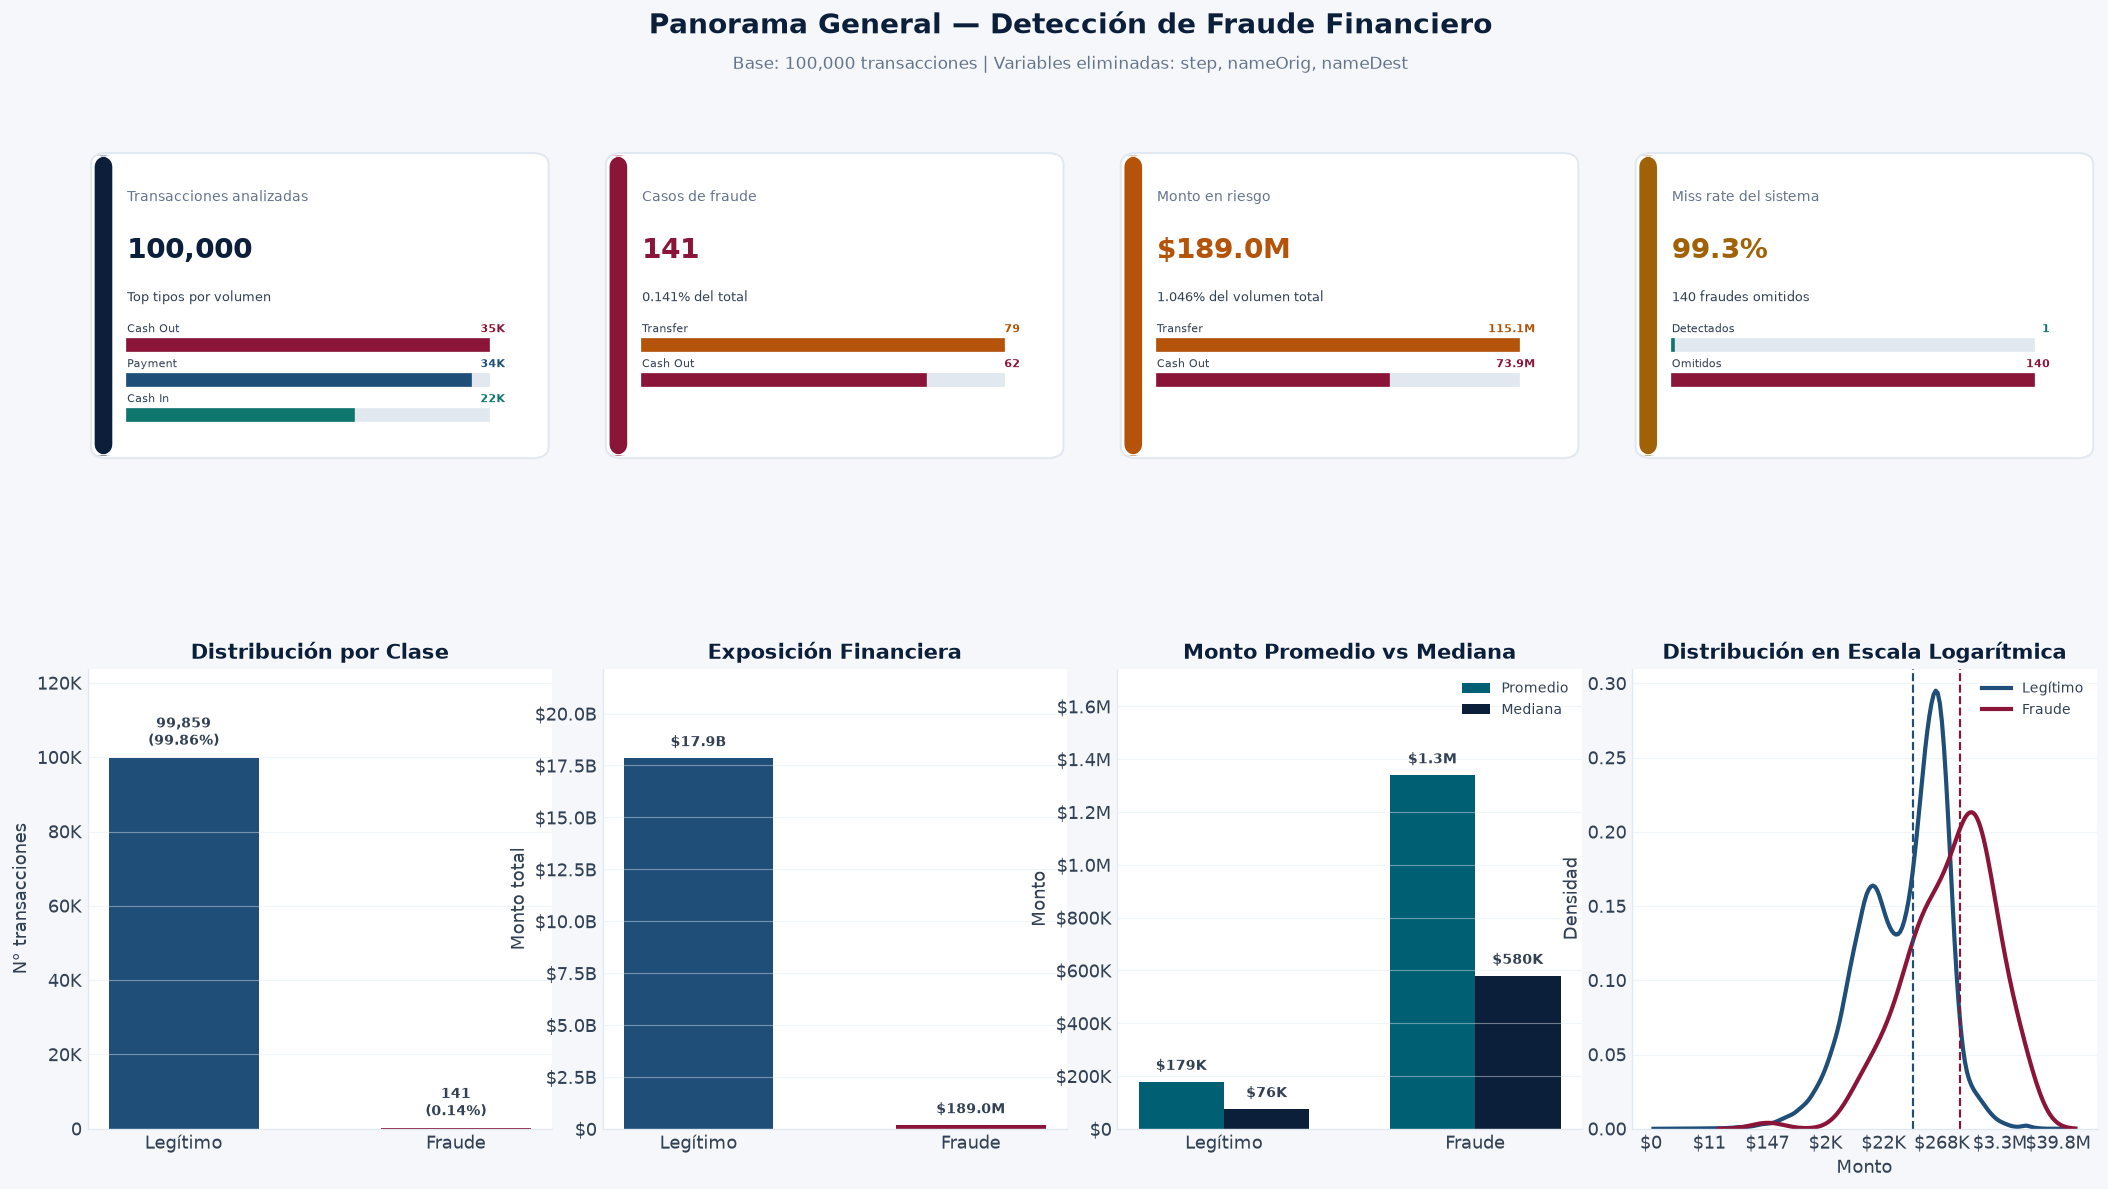

In [7]:
fig = plt.figure(figsize=(18, 10.2))

gs = gridspec.GridSpec(
    2, 12,
    figure=fig,
    height_ratios=[1.05, 1.45],
    hspace=0.50,
    wspace=0.42,
    top=0.88,
    bottom=0.07,
    left=0.045,
    right=0.975
)

fig.text(
    0.5, 0.965,
    "Panorama General — Detección de Fraude Financiero",
    ha="center",
    fontsize=17,
    fontweight="bold",
    color=C["navy"]
)

fig.text(
    0.5, 0.936,
    f"Base: {total_tx:,} transacciones | Variables eliminadas: step, nameOrig, nameDest",
    ha="center",
    fontsize=10,
    color=C["gray"]
)

tipo_counts = df["type"].value_counts()
fraud_type_counts = df_f["type"].value_counts()
fraud_type_amount = df_f.groupby("type")["amount"].sum().sort_values(ascending=False)

kpi_card_top(
    fig.add_subplot(gs[0, 0:3]),
    "Transacciones analizadas",
    f"{total_tx:,}",
    "Top tipos por volumen",
    C["navy"],
    tipo_counts.index,
    tipo_counts.values,
    [TYPE_COLORS.get(t, C["blue"]) for t in tipo_counts.index]
)

kpi_card_top(
    fig.add_subplot(gs[0, 3:6]),
    "Casos de fraude",
    f"{total_fraude:,}",
    f"{pct_fraude:.3f}% del total",
    C["burgundy"],
    fraud_type_counts.index,
    fraud_type_counts.values,
    [TYPE_COLORS.get(t, C["burgundy"]) for t in fraud_type_counts.index]
)

kpi_card_top(
    fig.add_subplot(gs[0, 6:9]),
    "Monto en riesgo",
    money_fmt(monto_fraude),
    f"{pct_monto_fraude:.3f}% del volumen total",
    C["copper"],
    fraud_type_amount.index,
    fraud_type_amount.values,
    [TYPE_COLORS.get(t, C["copper"]) for t in fraud_type_amount.index]
)

kpi_card_top(
    fig.add_subplot(gs[0, 9:12]),
    "Miss rate del sistema",
    f"{miss_rate:.1%}",
    f"{fn:,} fraudes omitidos",
    C["gold"],
    ["Detectados", "Omitidos"],
    [tp, fn],
    [C["teal"], C["burgundy"]]
)

ax1 = fig.add_subplot(gs[1, 0:3])
clase_counts = df["Clase"].value_counts().reindex(["Legítimo", "Fraude"]).fillna(0)

bars = ax1.bar(
    clase_counts.index,
    clase_counts.values,
    color=[FRAUD_COLORS[i] for i in clase_counts.index],
    width=0.55
)

ax1.set_title("Distribución por Clase", color=C["navy"])
ax1.set_ylabel("N° transacciones")
ax1.yaxis.set_major_formatter(mtick.FuncFormatter(count_fmt))
ax1.set_ylim(0, safe_max(clase_counts.values) * 1.24)

add_labels(
    ax1,
    bars,
    [f"{v:,.0f}\n({safe_pct(v, total_tx):.2f}%)" for v in clase_counts.values]
)

clean_ax(ax1)

ax2 = fig.add_subplot(gs[1, 3:6])
monto_clase = df.groupby("Clase")["amount"].sum().reindex(["Legítimo", "Fraude"]).fillna(0)

bars = ax2.bar(
    monto_clase.index,
    monto_clase.values,
    color=[FRAUD_COLORS[i] for i in monto_clase.index],
    width=0.55
)

ax2.set_title("Exposición Financiera", color=C["navy"])
ax2.set_ylabel("Monto total")
ax2.yaxis.set_major_formatter(mtick.FuncFormatter(money_fmt))
ax2.set_ylim(0, safe_max(monto_clase.values) * 1.24)

add_labels(ax2, bars, [money_fmt(v) for v in monto_clase.values])
clean_ax(ax2)

ax3 = fig.add_subplot(gs[1, 6:9])

tmp = pd.DataFrame({
    "Clase": ["Legítimo", "Fraude"],
    "Promedio": [avg_legit, avg_fraude],
    "Mediana": [med_legit, med_fraude],
})

x = np.arange(len(tmp))
w = 0.34

b1 = ax3.bar(x - w / 2, tmp["Promedio"], width=w, color=C["petrol"], label="Promedio")
b2 = ax3.bar(x + w / 2, tmp["Mediana"], width=w, color=C["navy"], label="Mediana")

ax3.set_xticks(x)
ax3.set_xticklabels(tmp["Clase"])
ax3.set_title("Monto Promedio vs Mediana", color=C["navy"])
ax3.set_ylabel("Monto")
ax3.yaxis.set_major_formatter(mtick.FuncFormatter(money_fmt))
ax3.set_ylim(0, max(tmp["Promedio"].max(), tmp["Mediana"].max(), 1) * 1.30)

add_labels(ax3, b1, [money_fmt(v) for v in tmp["Promedio"]])
add_labels(ax3, b2, [money_fmt(v) for v in tmp["Mediana"]])

ax3.legend(fontsize=8.5)
clean_ax(ax3)

ax4 = fig.add_subplot(gs[1, 9:12])

for clase, color in FRAUD_COLORS.items():
    temp = df[df["Clase"] == clase].copy()
    kde_line(ax4, temp, "amount_log", color, clase)

ax4.axvline(np.log1p(med_legit), color=C["blue"], linestyle="--", linewidth=1.3)
ax4.axvline(np.log1p(med_fraude), color=C["burgundy"], linestyle="--", linewidth=1.3)

ax4.set_title("Distribución en Escala Logarítmica", color=C["navy"])
ax4.set_xlabel("Monto")
ax4.set_ylabel("Densidad")
ax4.xaxis.set_major_formatter(mtick.FuncFormatter(money_from_log))
ax4.legend(fontsize=8.5)

clean_ax(ax4)

plt.show()

## Gráfica de contexto por tipo de transacción

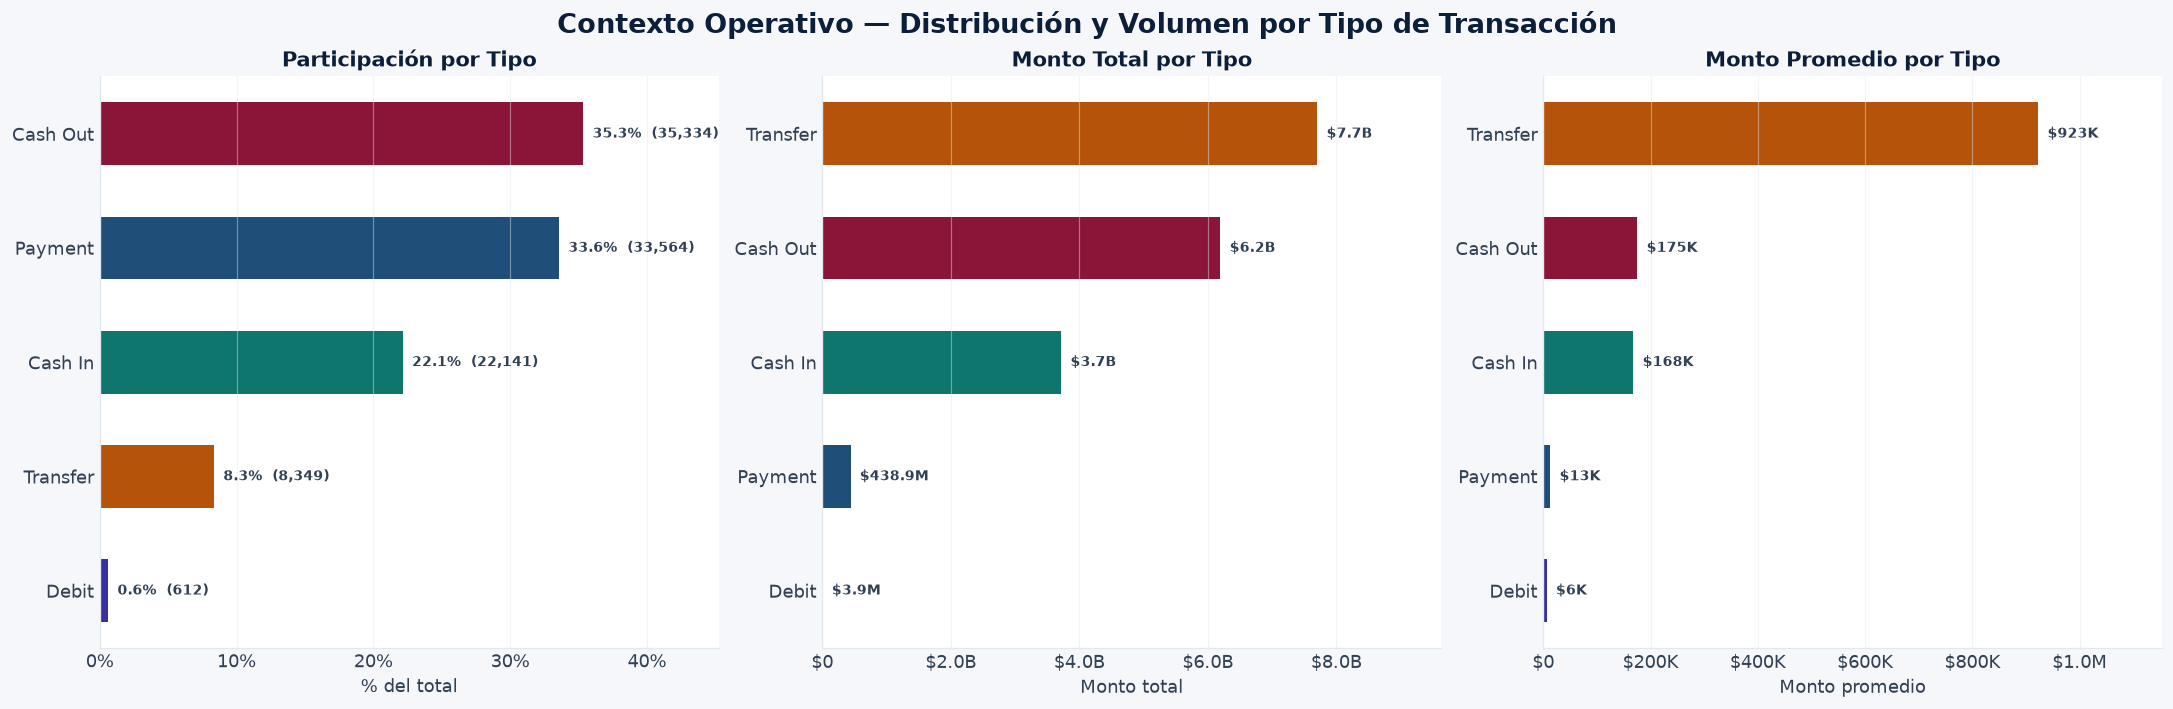

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5.8), constrained_layout=True)

fig.suptitle(
    "Contexto Operativo — Distribución y Volumen por Tipo de Transacción",
    fontsize=16,
    fontweight="bold",
    color=C["navy"]
)

ax = axes[0]
data = tipo_summary.sort_values("pct_tx", ascending=True)

bars = ax.barh(
    data["type"],
    data["pct_tx"],
    color=[TYPE_COLORS.get(t, C["blue_dark"]) for t in data["type"]],
    height=0.55
)

ax.set_title("Participación por Tipo", color=C["navy"])
ax.set_xlabel("% del total")
ax.xaxis.set_major_formatter(mtick.FuncFormatter(pct_fmt_int))
ax.set_xlim(0, safe_max(data["pct_tx"]) * 1.28)

add_labels(
    ax,
    bars,
    [f"{p:.1f}%  ({n:,.0f})" for p, n in zip(data["pct_tx"], data["total_tx"])],
    horizontal=True
)

clean_ax(ax, "x")

ax = axes[1]
data = tipo_summary.sort_values("monto_total", ascending=True)

bars = ax.barh(
    data["type"],
    data["monto_total"],
    color=[TYPE_COLORS.get(t, C["blue_dark"]) for t in data["type"]],
    height=0.55
)

ax.set_title("Monto Total por Tipo", color=C["navy"])
ax.set_xlabel("Monto total")
ax.xaxis.set_major_formatter(mtick.FuncFormatter(money_fmt))
ax.set_xlim(0, safe_max(data["monto_total"]) * 1.25)

add_labels(ax, bars, [money_fmt(v) for v in data["monto_total"]], horizontal=True)
clean_ax(ax, "x")

ax = axes[2]
data = tipo_summary.sort_values("monto_promedio", ascending=True)

bars = ax.barh(
    data["type"],
    data["monto_promedio"],
    color=[TYPE_COLORS.get(t, C["blue_dark"]) for t in data["type"]],
    height=0.55
)

ax.set_title("Monto Promedio por Tipo", color=C["navy"])
ax.set_xlabel("Monto promedio")
ax.xaxis.set_major_formatter(mtick.FuncFormatter(money_fmt))
ax.set_xlim(0, safe_max(data["monto_promedio"]) * 1.25)

add_labels(ax, bars, [money_fmt(v) for v in data["monto_promedio"]], horizontal=True)
clean_ax(ax, "x")

plt.show()

## Gráfica de concentración del fraude

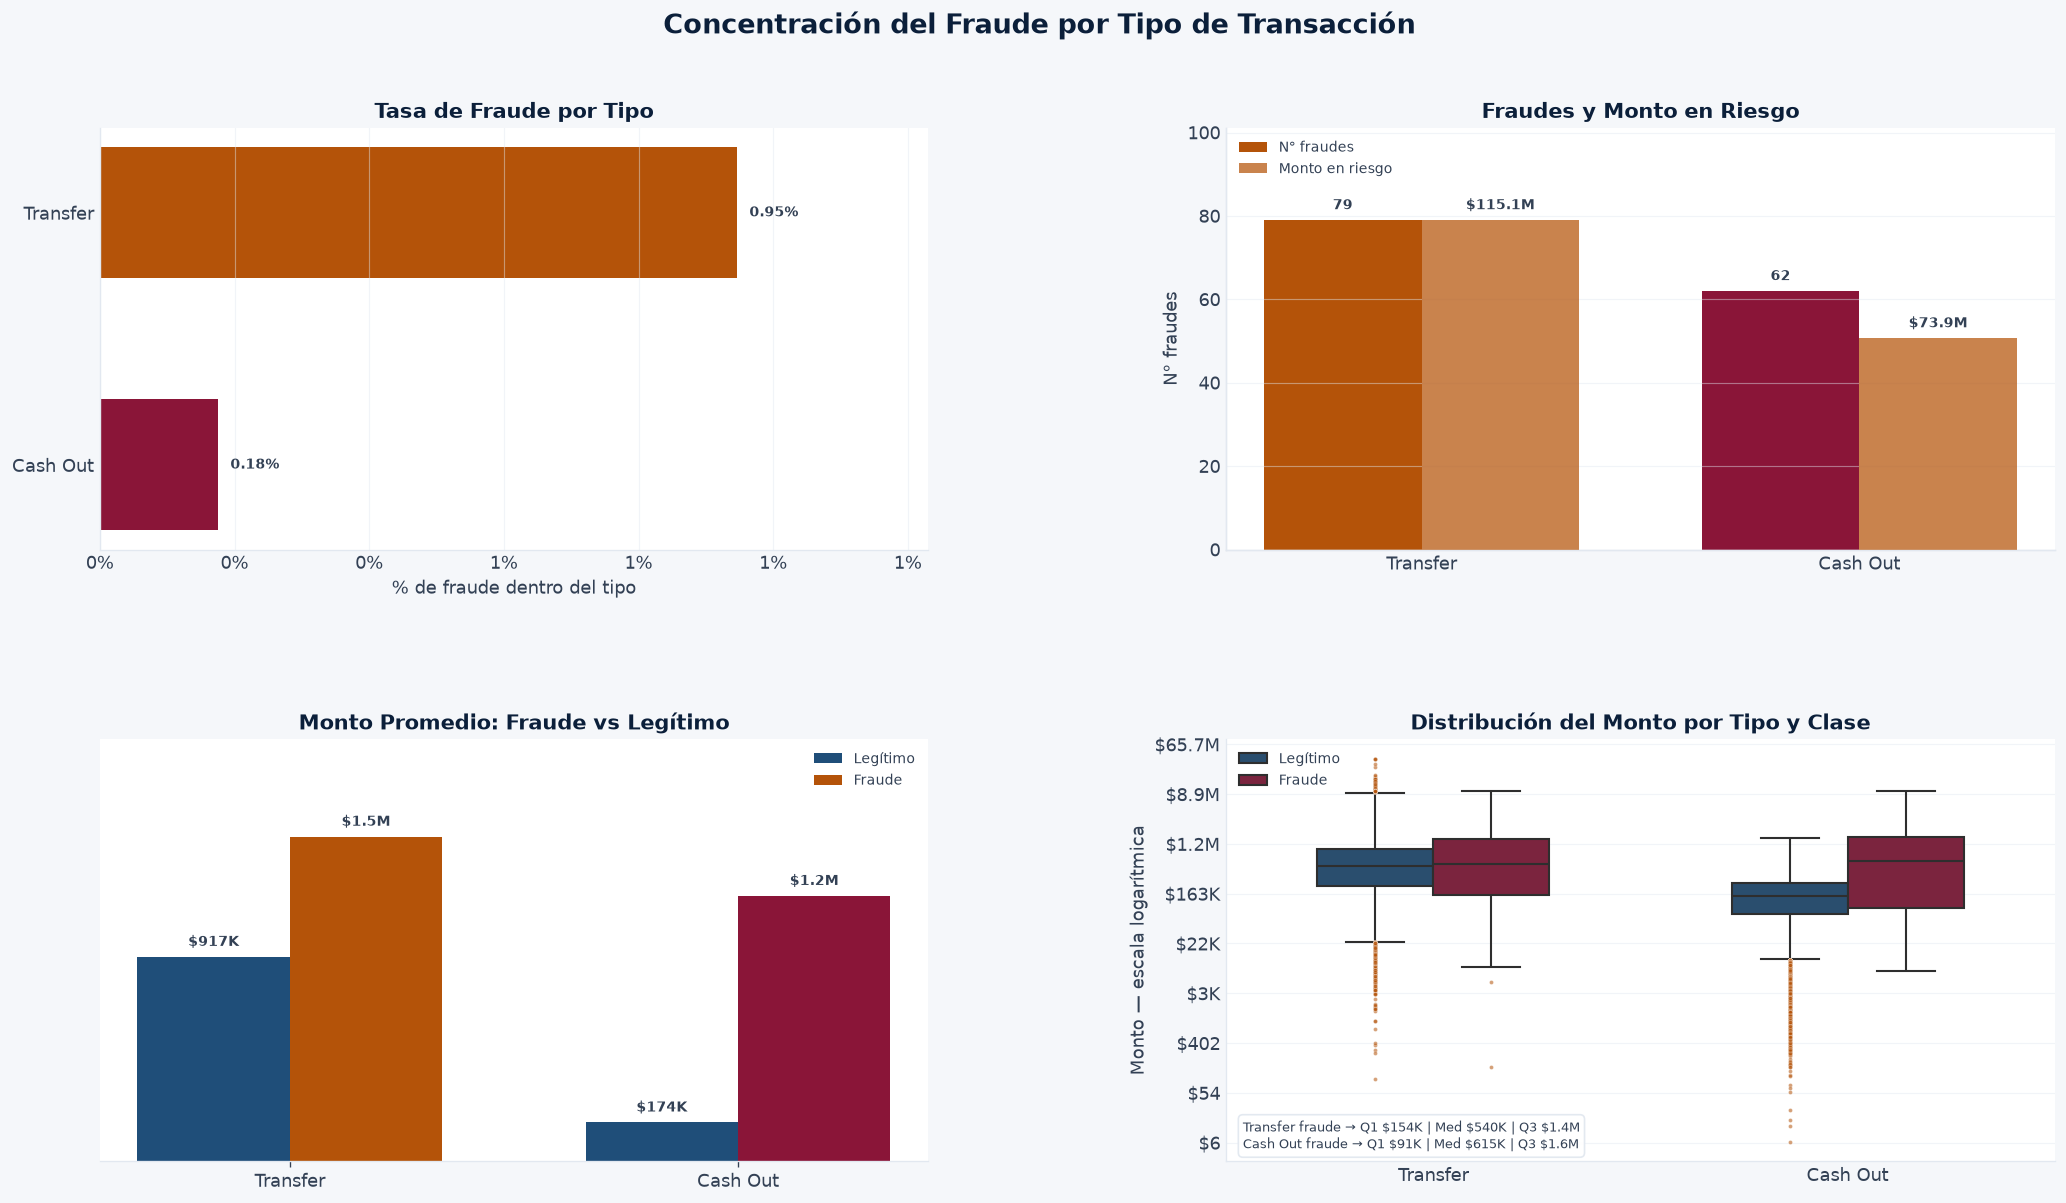

In [9]:
if len(fraud_focus) > 0:
    fig = plt.figure(figsize=(18, 10.5))

    gs = gridspec.GridSpec(
        2, 2,
        figure=fig,
        hspace=0.45,
        wspace=0.36,
        top=0.90,
        bottom=0.08,
        left=0.065,
        right=0.97
    )

    fig.text(
        0.5, 0.975,
        "Concentración del Fraude por Tipo de Transacción",
        ha="center",
        fontsize=16,
        fontweight="bold",
        color=C["navy"]
    )

    ax1 = fig.add_subplot(gs[0, 0])
    data = fraud_focus.sort_values("tasa_fraude", ascending=True)

    bars = ax1.barh(
        data["type"],
        data["tasa_fraude"],
        color=[TYPE_COLORS.get(t, C["burgundy"]) for t in data["type"]],
        height=0.52
    )

    ax1.set_title("Tasa de Fraude por Tipo", color=C["navy"])
    ax1.set_xlabel("% de fraude dentro del tipo")
    ax1.xaxis.set_major_formatter(mtick.FuncFormatter(pct_fmt_int))
    ax1.set_xlim(0, safe_max(data["tasa_fraude"]) * 1.30)

    add_labels(ax1, bars, [f"{v:.2f}%" for v in data["tasa_fraude"]], horizontal=True)
    clean_ax(ax1, "x")

    ax2 = fig.add_subplot(gs[0, 1])
    ax2r = ax2.twinx()

    data = fraud_focus.sort_values("n_fraudes", ascending=False)

    x = np.arange(len(data))
    w = 0.36

    b1 = ax2.bar(
        x - w / 2,
        data["n_fraudes"],
        width=w,
        color=[TYPE_COLORS.get(t, C["burgundy"]) for t in data["type"]],
        label="N° fraudes"
    )

    b2 = ax2r.bar(
        x + w / 2,
        data["monto_fraude"],
        width=w,
        color=C["copper"],
        alpha=0.72,
        label="Monto en riesgo"
    )

    ax2.set_xticks(x)
    ax2.set_xticklabels(data["type"])
    ax2.set_title("Fraudes y Monto en Riesgo", color=C["navy"])
    ax2.set_ylabel("N° fraudes")
    ax2.yaxis.set_major_formatter(mtick.FuncFormatter(count_fmt))

    ax2r.set_ylabel("")
    ax2r.set_yticks([])
    ax2r.spines[["top", "right"]].set_visible(False)

    ax2.set_ylim(0, safe_max(data["n_fraudes"]) * 1.28)
    ax2r.set_ylim(0, safe_max(data["monto_fraude"]) * 1.28)

    add_labels(ax2, b1, [f"{v:,.0f}" for v in data["n_fraudes"]])
    add_labels(ax2r, b2, [money_fmt(v) for v in data["monto_fraude"]])

    ax2.legend([b1, b2], ["N° fraudes", "Monto en riesgo"], fontsize=8.5, loc="upper left")
    clean_ax(ax2)

    ax3 = fig.add_subplot(gs[1, 0])

    order = fraud_focus.sort_values("monto_fraude", ascending=False)["type"].tolist()

    legit_avg = (
        df_l[df_l["type"].isin(order)]
        .groupby("type")["amount"]
        .mean()
        .reindex(order)
        .fillna(0)
    )

    fraud_avg = fraud_focus.set_index("type").reindex(order)["avg_fraude"].fillna(0)

    x = np.arange(len(order))
    w = 0.34

    b1 = ax3.bar(
        x - w / 2,
        legit_avg.values,
        width=w,
        color=C["blue"],
        label="Legítimo"
    )

    b2 = ax3.bar(
        x + w / 2,
        fraud_avg.values,
        width=w,
        color=[TYPE_COLORS.get(t, C["burgundy"]) for t in order],
        label="Fraude"
    )

    ax3.set_xticks(x)
    ax3.set_xticklabels(order)
    ax3.set_title("Monto Promedio: Fraude vs Legítimo", color=C["navy"])
    ax3.set_ylabel("")
    ax3.set_yticks([])
    ax3.grid(False)
    ax3.spines[["top", "right", "left"]].set_visible(False)

    ax3.set_ylim(0, max(safe_max(legit_avg.values), safe_max(fraud_avg.values)) * 1.30)

    add_labels(ax3, b1, [money_fmt(v) for v in legit_avg.values])
    add_labels(ax3, b2, [money_fmt(v) for v in fraud_avg.values])

    ax3.legend(fontsize=8.5)

    ax4 = fig.add_subplot(gs[1, 1])

    plot_box = df[df["type"].isin(order)].copy()
    plot_box["amount_log"] = np.log1p(plot_box["amount"])

    sns.boxplot(
        data=plot_box,
        x="type",
        y="amount_log",
        hue="Clase",
        order=order,
        hue_order=["Legítimo", "Fraude"],
        palette=FRAUD_COLORS,
        width=0.56,
        linewidth=1.25,
        flierprops=dict(
            marker="o",
            markersize=2.4,
            markerfacecolor=C["copper"],
            markeredgecolor=C["white"],
            markeredgewidth=0.25,
            alpha=0.55
        ),
        ax=ax4
    )

    ax4.set_title("Distribución del Monto por Tipo y Clase", color=C["navy"])
    ax4.set_xlabel("")
    ax4.set_ylabel("Monto — escala logarítmica")
    ax4.yaxis.set_major_formatter(mtick.FuncFormatter(money_from_log))
    ax4.legend(title="", fontsize=8.5, loc="upper left")

    clean_ax(ax4)

    txt = []

    for t in order:
        fraud_values = plot_box[
            (plot_box["type"] == t) &
            (plot_box["Clase"] == "Fraude")
        ]["amount"]

        if len(fraud_values):
            q1_f = fraud_values.quantile(0.25)
            med_f = fraud_values.median()
            q3_f = fraud_values.quantile(0.75)

            txt.append(
                f"{t} fraude → Q1 {money_fmt(q1_f)} | Med {money_fmt(med_f)} | Q3 {money_fmt(q3_f)}"
            )

    if txt:
        ax4.text(
            0.02,
            0.02,
            "\n".join(txt),
            transform=ax4.transAxes,
            fontsize=7.8,
            color=C["slate"],
            ha="left",
            va="bottom",
            bbox=dict(
                boxstyle="round,pad=0.35",
                fc=C["white"],
                ec=C["gray_light"],
                alpha=0.95
            )
        )

    plt.show()
else:
    print("No existen fraudes registrados para graficar concentración.")

## Gráfica de montos y outliers

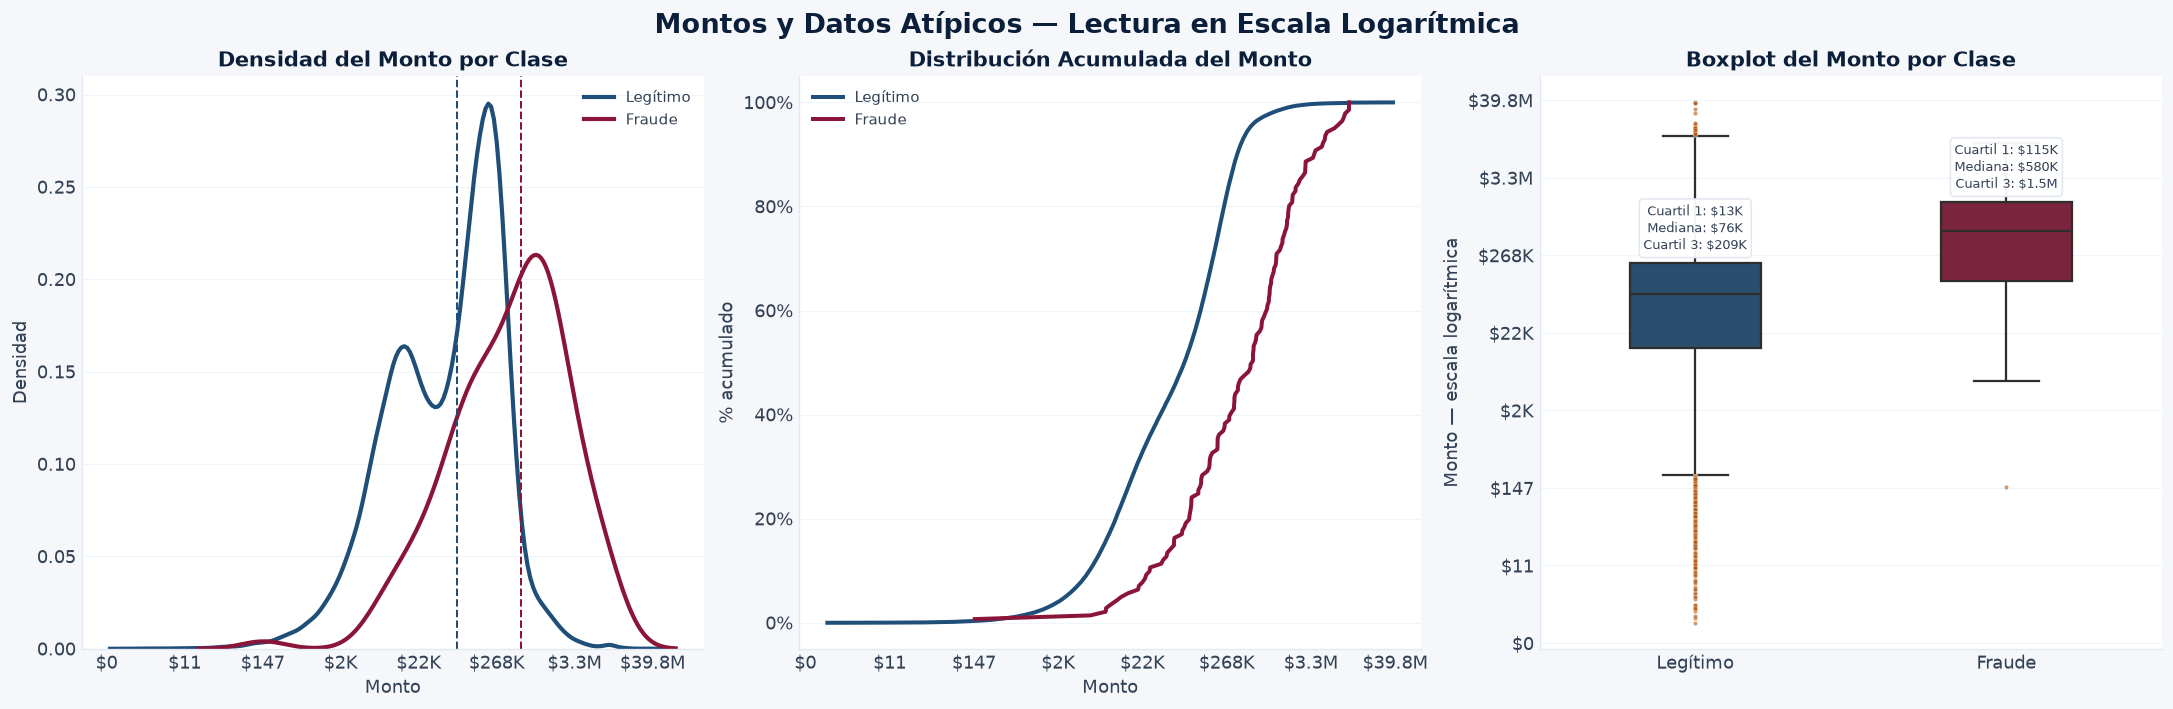

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5.8), constrained_layout=True)

fig.suptitle(
    "Montos y Datos Atípicos — Lectura en Escala Logarítmica",
    fontsize=16,
    fontweight="bold",
    color=C["navy"]
)

ax = axes[0]

for clase, color in FRAUD_COLORS.items():
    temp = df[df["Clase"] == clase].copy()
    kde_line(ax, temp, "amount_log", color, clase)

ax.axvline(np.log1p(med_legit), color=C["blue"], linestyle="--", linewidth=1.2)
ax.axvline(np.log1p(med_fraude), color=C["burgundy"], linestyle="--", linewidth=1.2)

ax.set_title("Densidad del Monto por Clase", color=C["navy"])
ax.set_xlabel("Monto")
ax.set_ylabel("Densidad")
ax.xaxis.set_major_formatter(mtick.FuncFormatter(money_from_log))
ax.legend(fontsize=9)

clean_ax(ax)

ax = axes[1]

for clase, color in FRAUD_COLORS.items():
    temp = df[df["Clase"] == clase].sort_values("amount_log")

    if len(temp):
        y = np.arange(1, len(temp) + 1) / len(temp)

        ax.plot(
            temp["amount_log"],
            y,
            color=color,
            linewidth=2.4,
            label=clase
        )

ax.set_title("Distribución Acumulada del Monto", color=C["navy"])
ax.set_xlabel("Monto")
ax.set_ylabel("% acumulado")
ax.xaxis.set_major_formatter(mtick.FuncFormatter(money_from_log))
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.legend(fontsize=9)

clean_ax(ax)

ax = axes[2]

sns.boxplot(
    data=df,
    x="Clase",
    y="amount_log",
    order=["Legítimo", "Fraude"],
    palette=FRAUD_COLORS,
    width=0.42,
    linewidth=1.35,
    flierprops=dict(
        marker="o",
        markersize=2.6,
        markerfacecolor=C["copper"],
        markeredgecolor=C["white"],
        markeredgewidth=0.25,
        alpha=0.58
    ),
    ax=ax
)

ax.set_title("Boxplot del Monto por Clase", color=C["navy"])
ax.set_xlabel("")
ax.set_ylabel("Monto — escala logarítmica")
ax.yaxis.set_major_formatter(mtick.FuncFormatter(money_from_log))

clean_ax(ax)

for i, clase in enumerate(["Legítimo", "Fraude"]):
    temp = df[df["Clase"] == clase]["amount"]

    if len(temp):
        q1_c = temp.quantile(0.25)
        med_c = temp.median()
        q3_c = temp.quantile(0.75)

        ax.text(
            i,
            np.log1p(q3_c) + 0.45,
            f"Cuartil 1: {money_fmt(q1_c)}\nMediana: {money_fmt(med_c)}\nCuartil 3: {money_fmt(q3_c)}",
            ha="center",
            fontsize=8,
            color=C["slate"],
            bbox=dict(
                boxstyle="round,pad=0.30",
                fc=C["white"],
                ec=C["gray_light"],
                alpha=0.95
            )
        )

plt.show()

## Gráfica de señales de balance

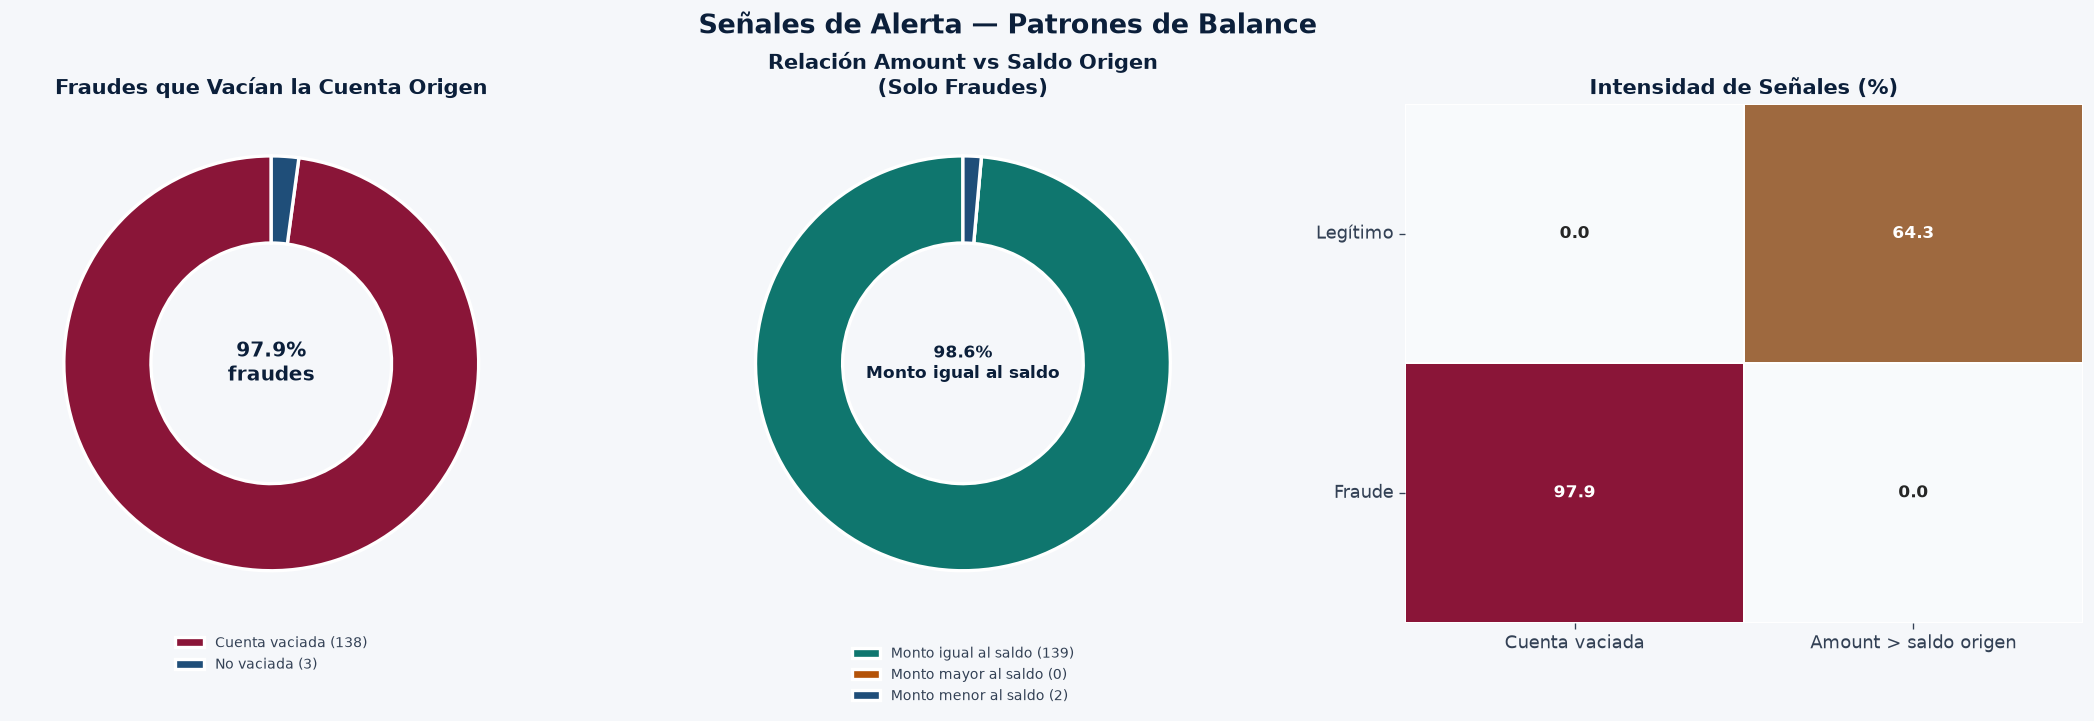

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5.9), constrained_layout=True)

fig.suptitle(
    "Señales de Alerta — Patrones de Balance",
    fontsize=16,
    fontweight="bold",
    color=C["navy"]
)

ax = axes[0]

vaciada = int(df_f["cuenta_vaciada"].sum())
no_vaciada = len(df_f) - vaciada

vals = [vaciada, no_vaciada]
labels = ["Cuenta vaciada", "No vaciada"]
colors = [C["burgundy"], C["blue"]]

wedges, _ = ax.pie(
    vals,
    startangle=90,
    colors=colors,
    wedgeprops=dict(width=0.42, edgecolor=C["white"], linewidth=2)
)

pct_v = safe_pct(vaciada, len(df_f))

ax.text(
    0,
    0,
    f"{pct_v:.1f}%\nfraudes",
    ha="center",
    va="center",
    fontsize=12,
    fontweight="bold",
    color=C["navy"]
)

ax.set_title("Fraudes que Vacían la Cuenta Origen", color=C["navy"])

ax.legend(
    wedges,
    [f"{l} ({v:,.0f})" for l, v in zip(labels, vals)],
    loc="lower center",
    bbox_to_anchor=(0.5, -0.12),
    fontsize=8.5
)

ax = axes[1]

fraud_balance_case = pd.Series({
    "Monto igual al saldo": int(((df_f["oldbalanceOrg"] > 0) & np.isclose(df_f["amount"], df_f["oldbalanceOrg"])).sum()),
    "Monto mayor al saldo": int((df_f["amount"] > df_f["oldbalanceOrg"]).sum()),
    "Monto menor al saldo": int((df_f["amount"] < df_f["oldbalanceOrg"]).sum()),
})

colors_case = [C["teal"], C["copper"], C["blue"]]

wedges, _ = ax.pie(
    fraud_balance_case.values,
    startangle=90,
    colors=colors_case,
    wedgeprops=dict(width=0.42, edgecolor=C["white"], linewidth=2)
)

main_case = fraud_balance_case.idxmax()
main_pct = safe_pct(fraud_balance_case.max(), fraud_balance_case.sum())

ax.text(
    0,
    0,
    f"{main_pct:.1f}%\n{main_case}",
    ha="center",
    va="center",
    fontsize=10.2,
    fontweight="bold",
    color=C["navy"]
)

ax.set_title("Relación Amount vs Saldo Origen\n(Solo Fraudes)", color=C["navy"])

ax.legend(
    wedges,
    [f"{k} ({v:,.0f})" for k, v in fraud_balance_case.items()],
    loc="lower center",
    bbox_to_anchor=(0.5, -0.18),
    fontsize=8.3
)

ax = axes[2]

signal_df = pd.DataFrame({
    "Cuenta vaciada": df.groupby("Clase")["cuenta_vaciada"].mean() * 100,
    "Amount > saldo origen": df.groupby("Clase")["amount_gt_balance"].mean() * 100,
}).reindex(["Legítimo", "Fraude"])

sns.heatmap(
    signal_df,
    annot=True,
    fmt=".1f",
    cmap=HEATMAP_CMAP,
    cbar=False,
    linewidths=1,
    linecolor=C["white"],
    annot_kws={"fontsize": 10, "fontweight": "bold"},
    ax=ax
)

ax.set_title("Intensidad de Señales (%)", color=C["navy"])
ax.set_xlabel("")
ax.set_ylabel("")
ax.tick_params(axis="x", rotation=0)
ax.tick_params(axis="y", rotation=0)

plt.show()

## Gráfica de mapa de riesgo y exposición

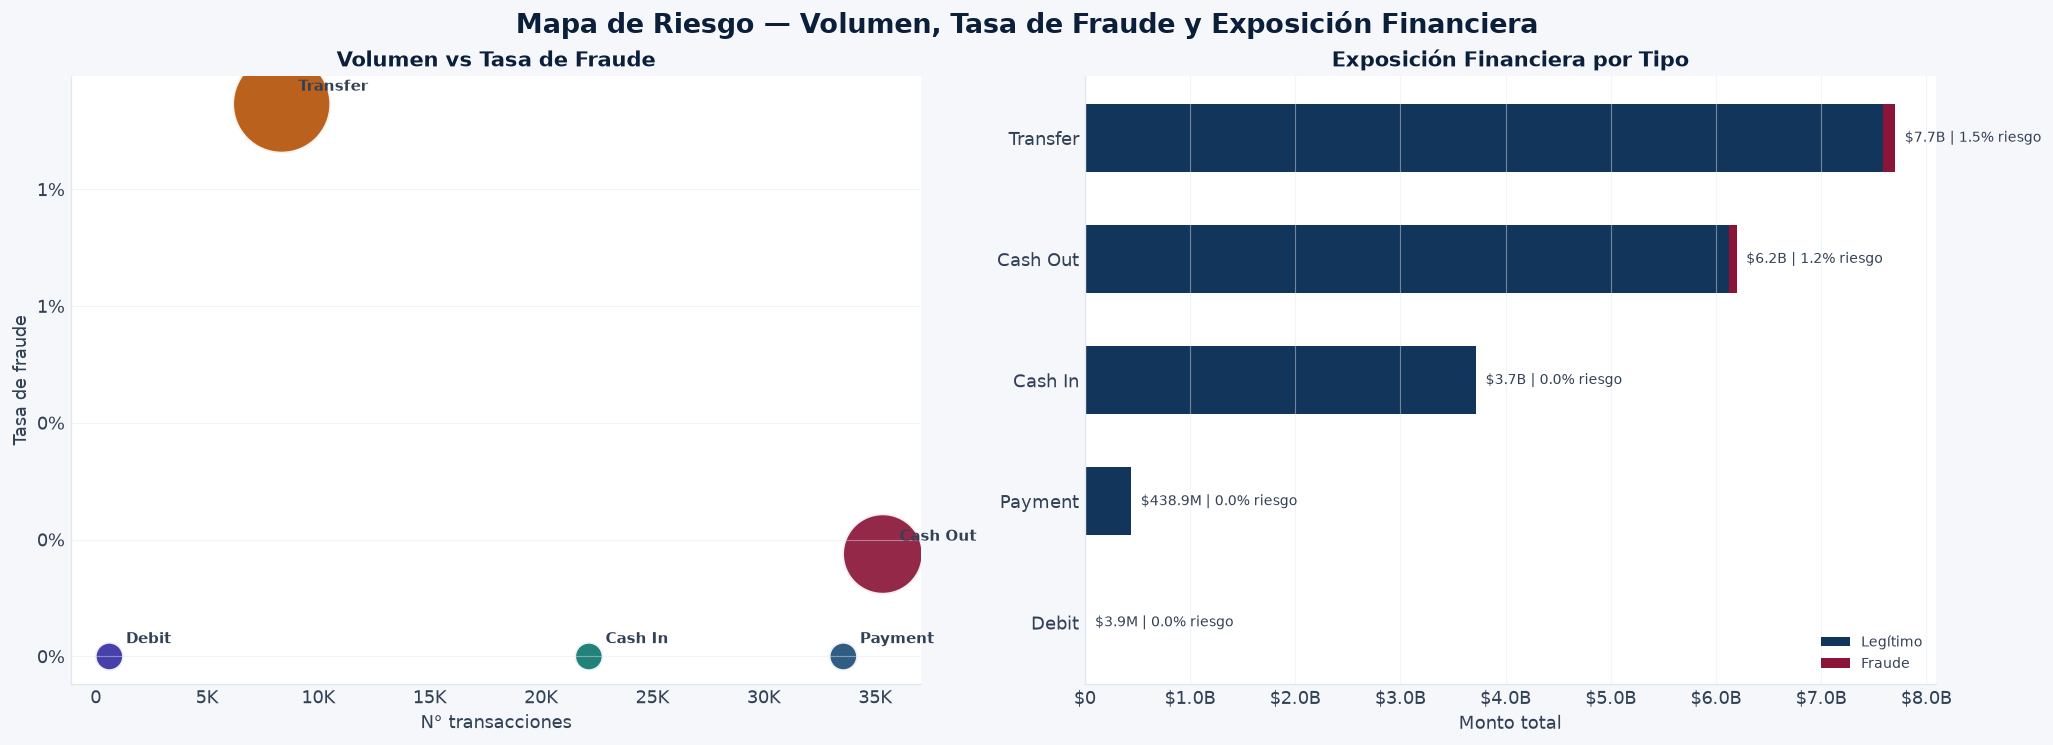

In [12]:
risk_map = df.groupby("type").agg(
    total_tx=("isFraud", "count"),
    tasa_fraude=("isFraud", lambda x: x.mean() * 100),
    monto_total=("amount", "sum"),
).reset_index()

risk_map = risk_map.merge(
    df_f.groupby("type")["amount"].sum().rename("monto_fraude"),
    on="type",
    how="left"
).fillna({"monto_fraude": 0})

fig, axes = plt.subplots(1, 2, figsize=(17, 6.1), constrained_layout=True)

fig.suptitle(
    "Mapa de Riesgo — Volumen, Tasa de Fraude y Exposición Financiera",
    fontsize=16,
    fontweight="bold",
    color=C["navy"]
)

ax = axes[0]

max_monto_f = risk_map["monto_fraude"].max()

if max_monto_f > 0:
    sizes = 300 + (risk_map["monto_fraude"] / max_monto_f) * 3200
else:
    sizes = np.repeat(600, len(risk_map))

ax.scatter(
    risk_map["total_tx"],
    risk_map["tasa_fraude"],
    s=sizes,
    c=[TYPE_COLORS.get(t, C["blue_dark"]) for t in risk_map["type"]],
    alpha=0.92,
    edgecolors=C["white"],
    linewidth=2.0
)

for _, row in risk_map.iterrows():
    ax.annotate(
        row["type"],
        (row["total_tx"], row["tasa_fraude"]),
        xytext=(10, 8),
        textcoords="offset points",
        fontsize=9,
        fontweight="bold",
        color=C["slate"]
    )

ax.set_title("Volumen vs Tasa de Fraude", color=C["navy"])
ax.set_xlabel("N° transacciones")
ax.set_ylabel("Tasa de fraude")
ax.xaxis.set_major_formatter(mtick.FuncFormatter(count_fmt))
ax.yaxis.set_major_formatter(mtick.FuncFormatter(pct_fmt_int))

clean_ax(ax)

ax = axes[1]

pivot = df.pivot_table(
    index="type",
    columns="Clase",
    values="amount",
    aggfunc="sum"
).fillna(0)

for col in ["Legítimo", "Fraude"]:
    if col not in pivot.columns:
        pivot[col] = 0

pivot["Total"] = pivot["Legítimo"] + pivot["Fraude"]
pivot = pivot.sort_values("Total", ascending=True)

left = np.zeros(len(pivot))

for clase, col in zip(["Legítimo", "Fraude"], [C["blue_dark"], C["burgundy"]]):
    vals = pivot[clase].values

    ax.barh(
        pivot.index,
        vals,
        left=left,
        color=col,
        height=0.56,
        label=clase
    )

    left += vals

for i, (_, row) in enumerate(pivot.iterrows()):
    pct_r = safe_pct(row["Fraude"], row["Total"])

    ax.text(
        row["Total"] + pivot["Total"].max() * 0.012,
        i,
        f"{money_fmt(row['Total'])} | {pct_r:.1f}% riesgo",
        va="center",
        fontsize=8.5,
        color=C["slate"]
    )

ax.set_title("Exposición Financiera por Tipo", color=C["navy"])
ax.set_xlabel("Monto total")
ax.xaxis.set_major_formatter(mtick.FuncFormatter(money_fmt))
ax.legend(fontsize=8.5, loc="lower right")

clean_ax(ax, "x")

plt.show()

## Gráfica de efectividad del sistema

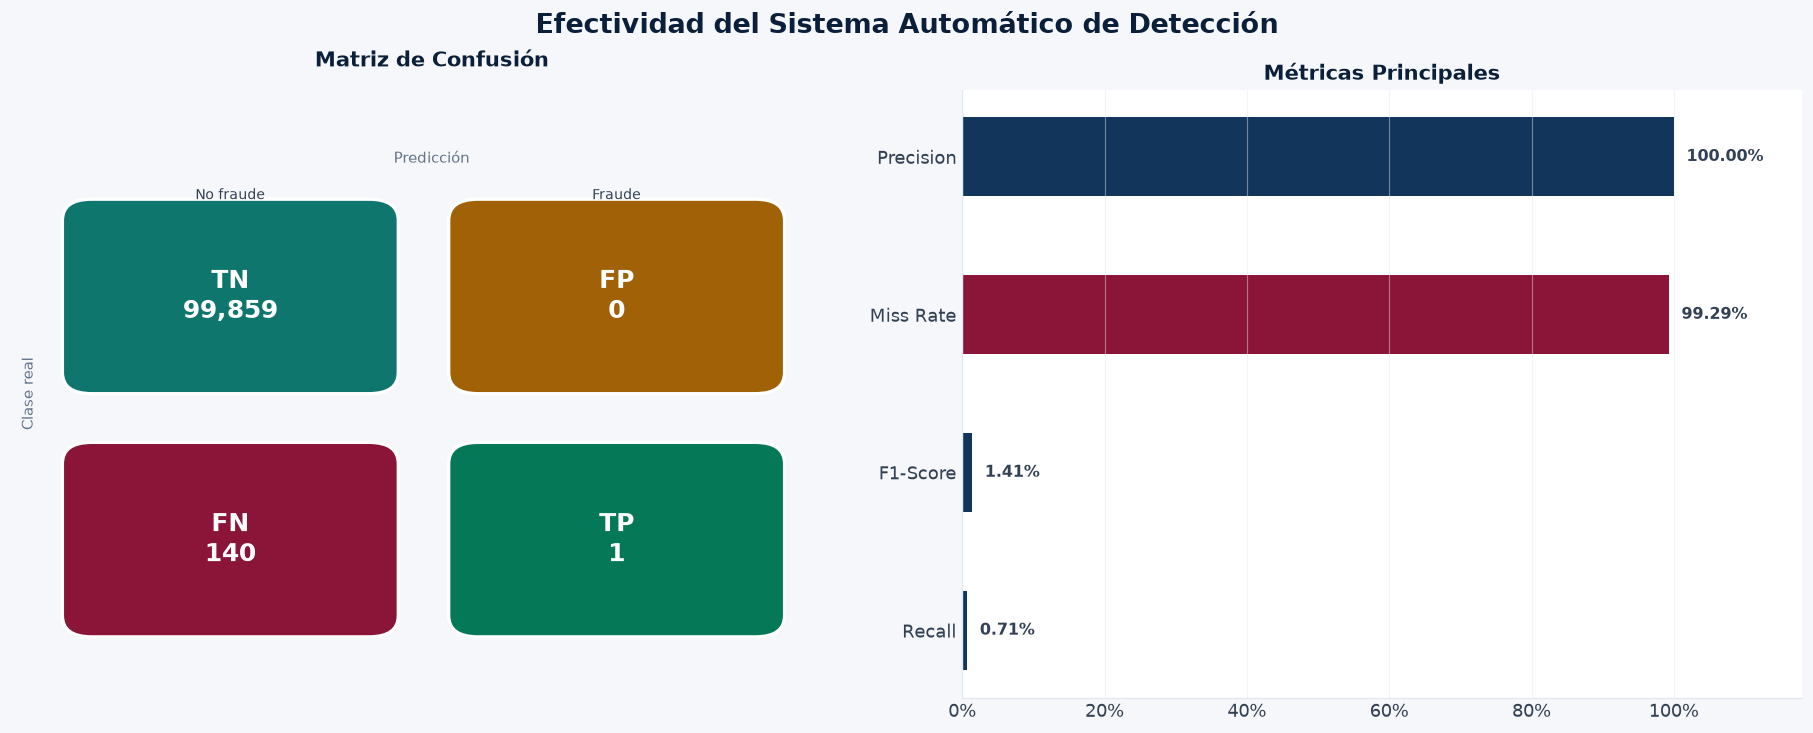

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6), constrained_layout=True)

fig.suptitle(
    "Efectividad del Sistema Automático de Detección",
    fontsize=16,
    fontweight="bold",
    color=C["navy"]
)

ax = axes[0]
ax.axis("off")
ax.set_title("Matriz de Confusión", color=C["navy"], pad=14)

cells = [
    (0.08, 0.52, "TN", tn, C["teal"]),
    (0.54, 0.52, "FP", fp, C["gold"]),
    (0.08, 0.12, "FN", fn, C["burgundy"]),
    (0.54, 0.12, "TP", tp, C["emerald"]),
]

for x0, y0, lab, val, col in cells:
    ax.add_patch(FancyBboxPatch(
        (x0, y0), 0.36, 0.28,
        boxstyle="round,pad=0.02,rounding_size=0.035",
        facecolor=col,
        edgecolor=C["white"],
        linewidth=2,
        transform=ax.transAxes
    ))

    ax.text(
        x0 + 0.18,
        y0 + 0.14,
        f"{lab}\n{val:,}",
        ha="center",
        va="center",
        fontsize=15,
        fontweight="bold",
        color=C["white"],
        transform=ax.transAxes
    )

ax.text(0.5, 0.88, "Predicción", ha="center", fontsize=9, color=C["gray"], transform=ax.transAxes)
ax.text(0.26, 0.82, "No fraude", ha="center", fontsize=8.5, transform=ax.transAxes)
ax.text(0.72, 0.82, "Fraude", ha="center", fontsize=8.5, transform=ax.transAxes)
ax.text(0.02, 0.5, "Clase real", ha="center", va="center", rotation=90,
        fontsize=9, color=C["gray"], transform=ax.transAxes)

ax = axes[1]

metrics = pd.Series({
    "Precision": precision,
    "Recall": recall,
    "F1-Score": f1,
    "Miss Rate": miss_rate
}).sort_values()

metric_colors = [
    C["burgundy"] if i == "Miss Rate" else C["blue_dark"]
    for i in metrics.index
]

bars = ax.barh(
    metrics.index,
    metrics.values,
    color=metric_colors,
    height=0.5
)

ax.set_title("Métricas Principales", color=C["navy"])
ax.set_xlim(0, 1.18)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))

add_labels(ax, bars, [f"{v:.2%}" for v in metrics.values], horizontal=True, fs=9.5)
clean_ax(ax, "x")

plt.show()

# Efectividad de nuevo sistema de deteccion